# SIPARTA: Sistem Pendeteksi Risiko Pencampuran Bahan Kimia Rumah Tangga (End-to-End Foundation)

Notebook ini merepresentasikan **seluruh evolusi riset SIPARTA** untuk kompetisi PKM-KC, dari validasi teori kimia hingga implementasi akhir pada Edge-AI (Raspberry Pi).

Alur penelitian dibagi menjadi tiga fase utama:
1. **Fase 1: Proof of Concept (Reaksi Kimia)** - Memvalidasi teori 10 parameter (pH, konsentrasi, dll) untuk memprediksi tingkat bahaya pencampuran kimia.
2. **Fase 2: Translasi Sensor Fisik (IoT)** - Mereduksi 10 parameter teoretis menjadi 4 parameter bacaan sensor gas aktual untuk implementasi hardware (Edge-AI).
3. **Fase 3: Simulasi IoT & Inference** - Menguji keandalan sistem klasifikasi dalam *loop* operasional perangkat keras.



In [ ]:
import os
import time
import json
import pickle
import logging
import requests
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

# Reprodusibilitas
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


---
# FASE 1: PROOF OF CONCEPT (Teori Reaksi Kimia)
Pada fase ini, model dilatih dengan **10 fitur teoretis** yang merepresentasikan parameter kimia (pH, viskositas, konsentrasi larutan, dll). Tujuannya adalah membuktikan bahwa kombinasi kimiawi dapat diklasifikasikan risikonya menjadi AMAN, WASPADA, dan BAHAYA.


In [ ]:
# ============================================================
# Definisi bahan kimia rumah tangga
# ============================================================
BAHAN_KIMIA = {
    0: {'nama': 'Pemutih (NaClO)',       'pH': 12.5, 'konsentrasi_default': 5.0},
    1: {'nama': 'Amonia (NH3)',           'pH': 11.5, 'konsentrasi_default': 10.0},
    2: {'nama': 'Cuka (CH3COOH)',         'pH': 2.5,  'konsentrasi_default': 5.0},
    3: {'nama': 'Sabun Cuci Piring',      'pH': 7.0,  'konsentrasi_default': 15.0},
    4: {'nama': 'Pembersih Lantai (HCl)', 'pH': 1.0,  'konsentrasi_default': 10.0},
    5: {'nama': 'Air (H2O)',              'pH': 7.0,  'konsentrasi_default': 100.0},
}

# ============================================================
# Aturan risiko pencampuran (berdasarkan kimia)
# ============================================================
# Key: tuple (min_id, max_id), Value: tingkat_risiko
RISIKO_CAMPURAN = {
    (0, 1): 2,  # Pemutih + Amonia   -> Gas Kloramin (TINGGI)
    (0, 2): 2,  # Pemutih + Cuka     -> Gas Klorin (TINGGI)
    (0, 4): 2,  # Pemutih + HCl      -> Gas Klorin (TINGGI)
    (1, 2): 1,  # Amonia + Cuka      -> Amonium Asetat (SEDANG - iritasi)
    (1, 4): 1,  # Amonia + HCl       -> Amonium Klorida asap (SEDANG)
    (2, 4): 1,  # Cuka + HCl         -> Campuran asam (SEDANG)
    (2, 3): 1,  # Cuka + Sabun       -> Netralkan surfaktan (SEDANG)
    (0, 3): 1,  # Pemutih + Sabun    -> Potensi gas klorin ringan (SEDANG)
    (0, 5): 0,  # Pemutih + Air      -> Encer (AMAN)
    (1, 5): 0,  # Amonia + Air       -> Encer (AMAN)
    (2, 5): 0,  # Cuka + Air         -> Encer (AMAN)
    (3, 5): 0,  # Sabun + Air        -> Normal (AMAN)
    (4, 5): 0,  # HCl + Air          -> Encer (AMAN)
    (3, 4): 0,  # Sabun + HCl        -> Umumnya aman (AMAN)
    (1, 3): 0,  # Amonia + Sabun     -> Umumnya aman (AMAN)
}

GAS_BERACUN = {
    (0, 1): 'Kloramin (NH2Cl)',
    (0, 2): 'Gas Klorin (Cl2)',
    (0, 4): 'Gas Klorin (Cl2)',
    (1, 2): 'Uap Amonium Asetat',
    (1, 4): 'Asap Amonium Klorida',
    (2, 4): 'Uap Asam',
    (2, 3): 'Tidak ada gas berbahaya',
    (0, 3): 'Gas Klorin ringan',
}

print("\u2705 Definisi bahan dan aturan risiko siap")
print(f"   Jumlah bahan      : {len(BAHAN_KIMIA)}")
print(f"   Jumlah kombinasi  : {len(RISIKO_CAMPURAN)}")


✅ Definisi bahan dan aturan risiko siap
   Jumlah bahan      : 6
   Jumlah kombinasi  : 15


In [ ]:
# ============================================================
# Generate dataset sintetis
# ============================================================
def generate_dataset(n_samples=3000, seed=42):
    """
    Membuat dataset sintetis pencampuran bahan kimia rumah tangga.
    Setiap sampel = satu skenario pencampuran dua bahan dengan variasi
    konsentrasi, suhu, ventilasi, dan volume.
    """
    rng = np.random.RandomState(seed)
    records = []

    kombinasi_list = list(RISIKO_CAMPURAN.keys())
    n_kombinasi = len(kombinasi_list)

    for i in range(n_samples):
        # Pilih kombinasi bahan secara acak
        idx = rng.randint(0, n_kombinasi)
        bahan_1, bahan_2 = kombinasi_list[idx]

        # Ambil properti bahan
        info_1 = BAHAN_KIMIA[bahan_1]
        info_2 = BAHAN_KIMIA[bahan_2]

        # Variasi konsentrasi (dengan noise)
        konsentrasi_1 = max(0.5, info_1['konsentrasi_default'] + rng.normal(0, 2))
        konsentrasi_2 = max(0.5, info_2['konsentrasi_default'] + rng.normal(0, 2))

        # pH (sedikit variasi)
        pH_1 = info_1['pH'] + rng.normal(0, 0.3)
        pH_2 = info_2['pH'] + rng.normal(0, 0.3)

        # Kondisi lingkungan
        suhu_ruangan = rng.uniform(20, 40)          # Celsius
        ventilasi = rng.uniform(0, 1)                # 0=tertutup, 1=terbuka
        volume_campuran = rng.uniform(50, 500)       # ml

        # Selisih pH (indikator reaksi asam-basa)
        delta_pH = abs(pH_1 - pH_2)

        # Risiko dasar dari aturan
        risiko_dasar = RISIKO_CAMPURAN[(bahan_1, bahan_2)]

        # Modifikasi risiko berdasarkan kondisi:
        # - Konsentrasi tinggi & volume besar bisa naikkan risiko
        # - Ventilasi baik bisa turunkan risiko
        # - Suhu tinggi mempercepat reaksi
        risiko_score = risiko_dasar

        # Faktor konsentrasi: konsentrasi tinggi -> risiko naik
        if konsentrasi_1 > info_1['konsentrasi_default'] * 1.3 and risiko_dasar > 0:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.7, 0.3]))

        # Faktor suhu: suhu > 35 bisa naikkan risiko
        if suhu_ruangan > 35 and risiko_dasar >= 1:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.6, 0.4]))

        # Faktor ventilasi: ventilasi bagus turunkan efek (tapi tetap beracun)
        if ventilasi > 0.8 and risiko_dasar == 1:
            risiko_score = max(0, risiko_score - rng.choice([0, 1], p=[0.6, 0.4]))

        # Noise kecil (5% kemungkinan salah label - real-world noise)
        if rng.random() < 0.03:
            risiko_score = rng.choice([0, 1, 2])

        records.append({
            'bahan_1': bahan_1,
            'bahan_2': bahan_2,
            'pH_bahan_1': round(pH_1, 2),
            'pH_bahan_2': round(pH_2, 2),
            'delta_pH': round(delta_pH, 2),
            'konsentrasi_1': round(konsentrasi_1, 2),
            'konsentrasi_2': round(konsentrasi_2, 2),
            'suhu_ruangan': round(suhu_ruangan, 2),
            'ventilasi': round(ventilasi, 4),
            'volume_campuran_ml': round(volume_campuran, 1),
            'tingkat_risiko': int(risiko_score),
        })

    return pd.DataFrame(records)


# Generate dataset
df = generate_dataset(n_samples=3000, seed=42)

print(f"\u2705 Dataset berhasil dibuat: {df.shape[0]} sampel, {df.shape[1]} kolom")
df.head(10)


✅ Dataset berhasil dibuat: 3000 sampel, 11 kolom


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
0,2,3,2.64,7.41,4.77,3.90,16.03,28.92,0.1000,256.7,1
1,0,3,12.33,6.72,5.61,3.84,13.95,30.50,0.4319,181.1,1
2,1,5,11.06,7.45,3.61,9.50,99.67,39.66,0.4668,437.0,0
3,0,5,12.32,7.56,4.76,3.80,99.42,22.44,0.4952,65.5,0
4,1,2,11.09,2.39,8.69,11.13,3.59,31.35,0.0313,429.0,1
5,1,5,11.20,6.53,4.67,10.44,101.76,25.43,0.8287,210.5,0
6,3,5,6.44,6.59,0.15,13.09,97.90,25.87,0.0141,139.5,0
7,0,4,12.60,1.29,11.31,3.32,9.38,26.62,0.0636,189.9,2
8,0,4,11.89,1.32,10.57,1.85,11.28,39.43,0.8489,374.8,2
9,2,5,2.53,6.91,4.38,0.50,101.64,26.29,0.5086,458.4,0


In [ ]:
# ============================================================
# Tambahkan kolom nama bahan (untuk eksplorasi)
# ============================================================
df['nama_bahan_1'] = df['bahan_1'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['nama_bahan_2'] = df['bahan_2'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['campuran'] = df['nama_bahan_1'] + ' + ' + df['nama_bahan_2']
df['label_risiko'] = df['tingkat_risiko'].map({0: 'Aman', 1: 'Sedang', 2: 'Tinggi'})

print("\nContoh data dengan nama bahan:")
df[['campuran', 'pH_bahan_1', 'pH_bahan_2', 'delta_pH',
    'konsentrasi_1', 'suhu_ruangan', 'ventilasi', 'label_risiko']].head(10)



Contoh data dengan nama bahan:


,campuran,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,suhu_ruangan,ventilasi,label_risiko
0,Cuka (CH3COOH) + Sabun Cuci Piring,2.64,7.41,4.77,3.90,28.92,0.1000,Sedang
1,Pemutih (NaClO) + Sabun Cuci Piring,12.33,6.72,5.61,3.84,30.50,0.4319,Sedang
2,Amonia (NH3) + Air (H2O),11.06,7.45,3.61,9.50,39.66,0.4668,Aman
3,Pemutih (NaClO) + Air (H2O),12.32,7.56,4.76,3.80,22.44,0.4952,Aman
4,Amonia (NH3) + Cuka (CH3COOH),11.09,2.39,8.69,11.13,31.35,0.0313,Sedang
5,Amonia (NH3) + Air (H2O),11.20,6.53,4.67,10.44,25.43,0.8287,Aman
6,Sabun Cuci Piring + Air (H2O),6.44,6.59,0.15,13.09,25.87,0.0141,Aman
7,Pemutih (NaClO) + Pembersih Lantai (HCl),12.60,1.29,11.31,3.32,26.62,0.0636,Tinggi
8,Pemutih (NaClO) + Pembersih Lantai (HCl),11.89,1.32,10.57,1.85,39.43,0.8489,Tinggi
9,Cuka (CH3COOH) + Air (H2O),2.53,6.91,4.38,0.50,26.29,0.5086,Aman


In [ ]:
# ============================================================
# Simpan dataset ke CSV (opsional - untuk digunakan kembali)
# ============================================================
df.to_csv('dataset_gas_beracun_siparta.csv', index=False)
print("\u2705 Dataset tersimpan: dataset_gas_beracun_siparta.csv")


✅ Dataset tersimpan: dataset_gas_beracun_siparta.csv


In [ ]:
# ============================================================
# Informasi Dataset
# ============================================================
print("=" * 60)
print("INFORMASI DATASET SIPARTA")
print("=" * 60)
print(f"Jumlah sampel  : {df.shape[0]}")
print(f"Jumlah fitur   : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nStatistik deskriptif:")
df.describe()


INFORMASI DATASET SIPARTA
Jumlah sampel  : 3000
Jumlah fitur   : 15
Missing values : 0

Tipe data:
bahan_1                 int64
bahan_2                 int64
pH_bahan_1            float64
pH_bahan_2            float64
delta_pH              float64
konsentrasi_1         float64
konsentrasi_2         float64
suhu_ruangan          float64
ventilasi             float64
volume_campuran_ml    float64
tingkat_risiko          int64
nama_bahan_1           object
nama_bahan_2           object
campuran               object
label_risiko           object
dtype: object

Statistik deskriptif:


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1.348667,3.674667,8.674290,5.104807,5.603513,8.021970,40.546250,29.958703,0.499374,279.758167,0.769333
std,1.252313,1.249004,4.366426,3.197731,3.317133,4.097818,42.386607,5.697311,0.290412,130.632134,0.820376
min,0.000000,1.000000,0.030000,0.090000,0.000000,0.500000,0.500000,20.000000,0.000200,50.800000,0.000000
25%,0.000000,3.000000,2.900000,1.400000,4.050000,4.800000,9.390000,25.050000,0.247375,167.500000,0.000000
50%,1.000000,4.000000,11.380000,6.720000,5.230000,7.320000,13.590000,29.935000,0.507300,282.400000,1.000000
75%,2.000000,5.000000,12.280000,7.120000,8.682500,10.752500,98.750000,34.835000,0.746125,394.500000,1.000000
max,4.000000,5.000000,13.320000,12.100000,12.670000,20.710000,105.710000,39.990000,0.999800,500.000000,2.000000


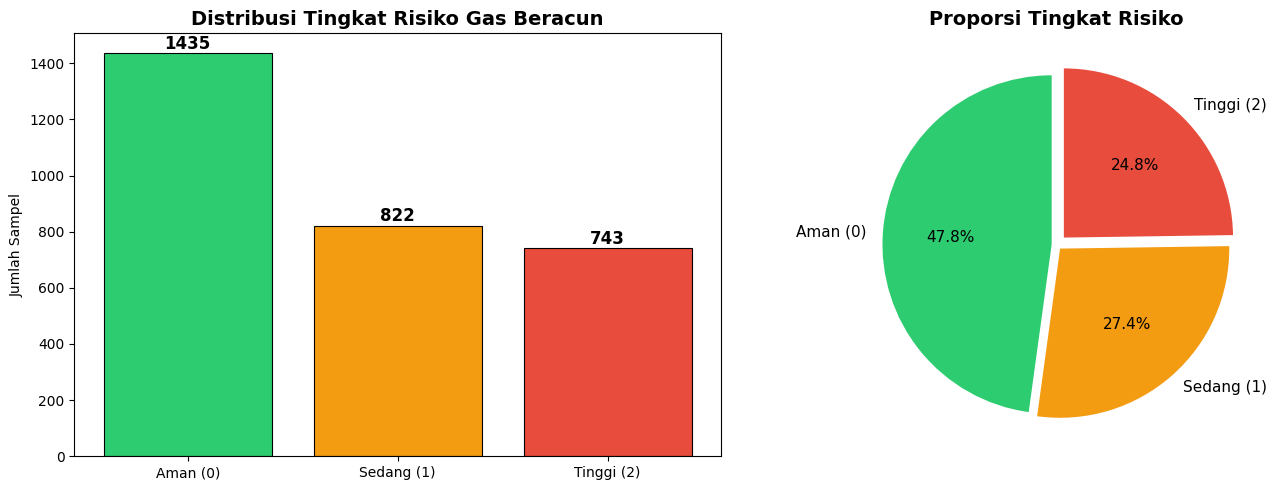

In [ ]:
# ============================================================
# Distribusi Tingkat Risiko
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
risk_counts = df['tingkat_risiko'].value_counts().sort_index()
risk_labels = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(risk_labels, risk_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Tingkat Risiko Gas Beracun', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 15, str(val),
                ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.03, 0.03, 0.06],
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Tingkat Risiko', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


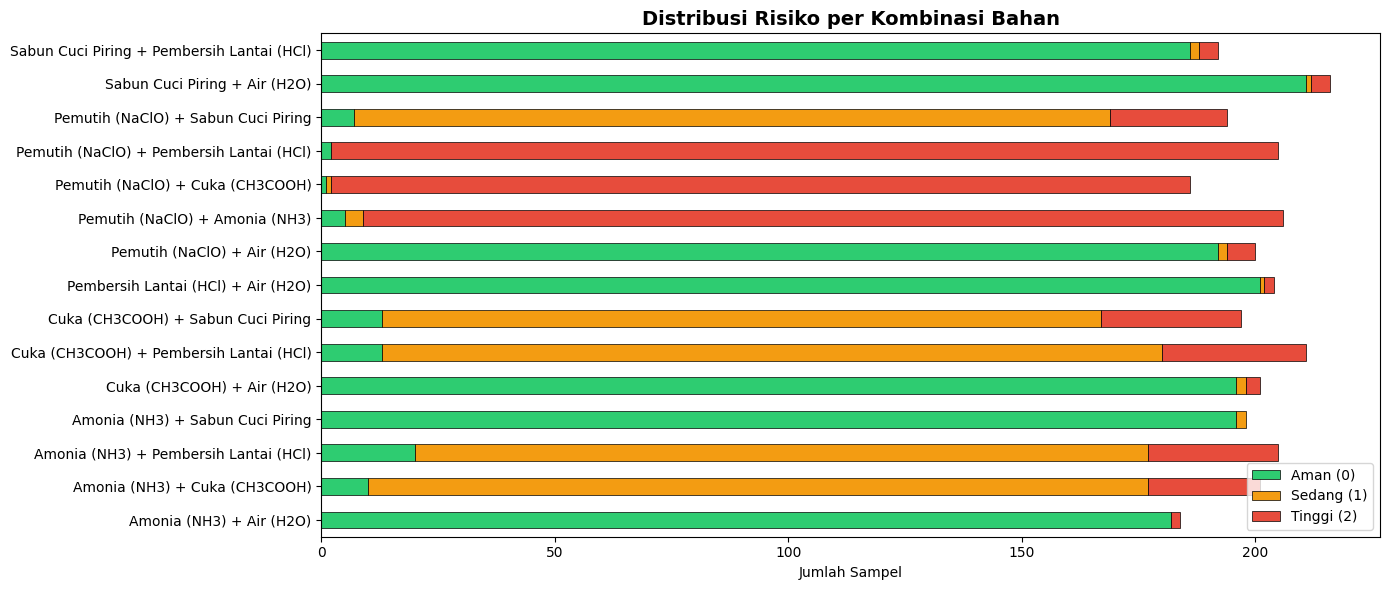

In [ ]:
# ============================================================
# Risiko per Kombinasi Bahan
# ============================================================
risk_by_mix = df.groupby(['campuran', 'tingkat_risiko']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
risk_by_mix.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Risiko per Kombinasi Bahan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Sampel')
ax.set_ylabel('')
ax.legend(['Aman (0)', 'Sedang (1)', 'Tinggi (2)'], loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Pilih fitur dan target
# ============================================================
FEATURE_COLUMNS = [
    'bahan_1', 'bahan_2',
    'pH_bahan_1', 'pH_bahan_2', 'delta_pH',
    'konsentrasi_1', 'konsentrasi_2',
    'suhu_ruangan', 'ventilasi', 'volume_campuran_ml'
]
TARGET_COLUMN = 'tingkat_risiko'
NUM_CLASSES = 3  # Aman, Sedang, Tinggi

X = df[FEATURE_COLUMNS].values
y = df[TARGET_COLUMN].values

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Kelas   : {np.unique(y)} (0=Aman, 1=Sedang, 2=Tinggi)")


Shape X : (3000, 10)
Shape y : (3000,)
Kelas   : [0 1 2] (0=Aman, 1=Sedang, 2=Tinggi)


In [ ]:
# ============================================================
# Split data: Train (70%), Validation (15%), Test (15%)
# ============================================================
X_p1_train, X_temp, y_p1_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_p1_val, X_p1_test, y_p1_val, y_p1_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Training set   : {X_p1_train.shape[0]} sampel ({X_p1_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_p1_val.shape[0]} sampel ({X_p1_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_p1_test.shape[0]} sampel ({X_p1_test.shape[0]/len(X)*100:.1f}%)")


Training set   : 2100 sampel (70.0%)
Validation set : 450 sampel (15.0%)
Test set       : 450 sampel (15.0%)


In [ ]:
# ============================================================
# Feature Scaling (StandardScaler)
# ============================================================
scaler_p1 = StandardScaler()
X_p1_train_scaled = scaler_p1.fit_transform(X_p1_train)
X_p1_val_scaled = scaler_p1.transform(X_p1_val)
X_p1_test_scaled = scaler_p1.transform(X_p1_test)

print("\u2705 Feature scaling selesai (StandardScaler)")
print(f"   Mean training (sesudah): {X_p1_train_scaled.mean():.6f}")
print(f"   Std training (sesudah) : {X_p1_train_scaled.std():.6f}")


✅ Feature scaling selesai (StandardScaler)
   Mean training (sesudah): -0.000000
   Std training (sesudah) : 1.000000


In [ ]:
# ============================================================
# One-Hot Encoding target (untuk multi-class classification)
# ============================================================
y_p1_train_cat = to_categorical(y_p1_train, num_classes=NUM_CLASSES)
y_p1_val_cat = to_categorical(y_p1_val, num_classes=NUM_CLASSES)
y_p1_test_cat = to_categorical(y_p1_test, num_classes=NUM_CLASSES)

print(f"\u2705 One-hot encoding selesai")
print(f"   y_p1_train shape: {y_p1_train_cat.shape}")
print(f"   Contoh: {y_p1_train[:5]} -> ")
print(f"           {y_p1_train_cat[:5]}")


✅ One-hot encoding selesai
   y_train shape: (2100, 3)
   Contoh: [0 0 0 2 0] -> 
           [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [ ]:
# ============================================================
# Hyperparameter
# ============================================================
INPUT_DIM = X_p1_train_scaled.shape[1]
LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 32

print(f"Input dimension : {INPUT_DIM}")
print(f"Output classes  : {NUM_CLASSES}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Epochs          : {EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")


Input dimension : 10
Output classes  : 3
Learning rate   : 0.001
Epochs          : 200
Batch size      : 32


In [ ]:
# ============================================================
# Bangun Model ANN
# ============================================================
def build_ann_model(input_dim, num_classes, learning_rate=0.001):
    """
    Membangun arsitektur ANN untuk klasifikasi tingkat risiko
    gas beracun dari reaksi kimia rumah tangga.

    Args:
        input_dim: Jumlah fitur input
        num_classes: Jumlah kelas output (3: Aman/Sedang/Tinggi)
        learning_rate: Learning rate untuk optimizer Adam

    Returns:
        model: Compiled Keras Sequential model
    """
    model_p1 = Sequential(name='SIPARTA_ANN')

    # Input + Hidden Layer 1
    model_p1.add(Input(shape=(input_dim,)))
    model_p1.add(Dense(128, activation='relu', kernel_initializer='he_normal', name='hidden_1'))
    model_p1.add(BatchNormalization(name='bn_1'))
    model_p1.add(Dropout(0.3, name='dropout_1'))

    # Hidden Layer 2
    model_p1.add(Dense(64, activation='relu', kernel_initializer='he_normal', name='hidden_2'))
    model_p1.add(BatchNormalization(name='bn_2'))
    model_p1.add(Dropout(0.3, name='dropout_2'))

    # Hidden Layer 3
    model_p1.add(Dense(32, activation='relu', kernel_initializer='he_normal', name='hidden_3'))
    model_p1.add(BatchNormalization(name='bn_3'))
    model_p1.add(Dropout(0.2, name='dropout_3'))

    # Output Layer (3 kelas: Aman, Sedang, Tinggi)
    model_p1.add(Dense(num_classes, activation='softmax', name='output'))

    # Compile
    optimizer = Adam(learning_rate=learning_rate)
    model_p1.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model_p1


# Buat model
model_p1 = build_ann_model(INPUT_DIM, NUM_CLASSES, LEARNING_RATE)

# Tampilkan arsitektur
model_p1.summary()


Model: "SIPARTA_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,739 (49.76 KB)

 Trainable params: 12,291 (48.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================
# Definisi Callbacks
# ============================================================

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    'siparta_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, checkpoint]
print("\u2705 Callbacks dikonfigurasi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")


✅ Callbacks dikonfigurasi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
# ============================================================
# Training
# ============================================================
print("\ud83d\ude80 Memulai training model SIPARTA ANN...\n")

history_p1 = model_p1.fit(
    X_p1_train_scaled, y_p1_train_cat,
    validation_data=(X_p1_val_scaled, y_p1_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\n\u2705 Training selesai!")
print(f"   Total epoch dijalankan: {len(history_p1.history['loss'])}")


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_s

54/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8999 - loss: 0.2931
Epoch 1: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9148 - loss: 0.2605 - val_accuracy: 0.9044 - val_loss: 0.2918 - learning_rate: 2.5000e-04
Epoch 2/200
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9029 - loss: 0.2977
Epoch 2: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9129 - loss: 0.2636 - val_accuracy: 0.9044 - val_loss: 0.2919 - learning_rate: 2.5000e-04
Epoch 3/200
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9026 - loss: 0.2916
Epoch 3: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9100 - loss: 0.2648 - val_accuracy: 0.9044 - val_loss: 0.2931 - learning_rate: 2.5000e-04
Epoch 4/200
60/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2857
Epoch 4: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/ste

In [ ]:
# ============================================================
# Evaluasi pada Test Set
# ============================================================
test_loss, test_accuracy = model_p1.evaluate(X_p1_test_scaled, y_p1_test_cat, verbose=0)

print("=" * 55)
print("  HASIL EVALUASI MODEL SIPARTA ANN - TEST SET")
print("=" * 55)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 55)


  HASIL EVALUASI MODEL SIPARTA ANN - TEST SET
  Test Loss     : 0.2540
  Test Accuracy : 0.9222 (92.22%)


In [ ]:
# ============================================================
# Prediksi & Classification Report
# ============================================================
y_pred_proba = model_p1.predict(X_p1_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
target_names = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
print(classification_report(y_p1_test, y_pred, target_names=target_names))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Aman (0)       0.97      0.96      0.97       215
  Sedang (1)       0.82      0.98      0.89       124
  Tinggi (2)       0.98      0.77      0.86       111

    accuracy                           0.92       450
   macro avg       0.92      0.91      0.91       450
weighted avg       0.93      0.92      0.92       450



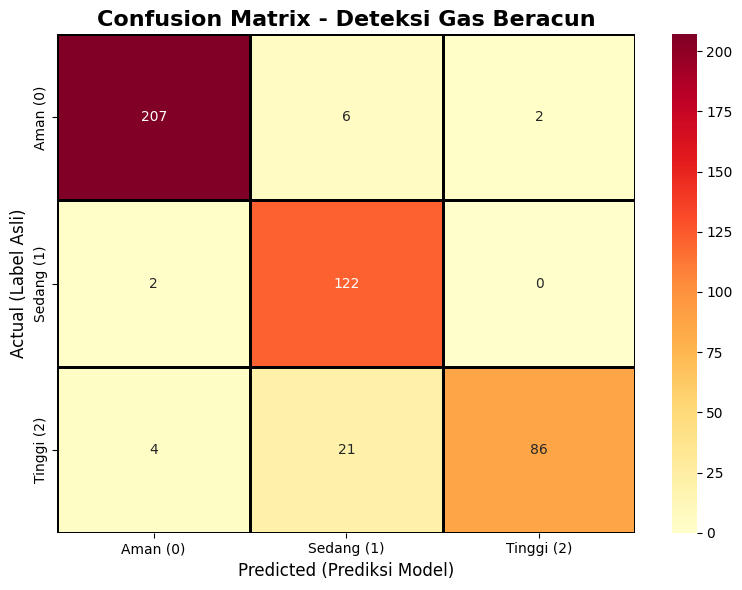


Akurasi per kelas:
  Aman (0): 0.9628 (207/215)
  Sedang (1): 0.9839 (122/124)
  Tinggi (2): 0.7748 (86/111)


In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_p1_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=target_names,
            yticklabels=target_names,
            linewidths=1, linecolor='black')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual (Label Asli)', fontsize=12)
plt.xlabel('Predicted (Prediksi Model)', fontsize=12)
plt.tight_layout()
plt.show()

# Hitung per-kelas accuracy
print("\nAkurasi per kelas:")
for i, name in enumerate(target_names):
    if cm[i].sum() > 0:
        acc = cm[i][i] / cm[i].sum()
        print(f"  {name}: {acc:.4f} ({cm[i][i]}/{cm[i].sum()})")


---
# FASE 2: TRANSLASI SENSOR FISIK & PELATIHAN EDGE AI (IoT)
Model dengan 10 fitur kimia di atas tidak dapat digunakan secara langsung pada alat fisik karena sensor yang digunakan (MQ-2, MQ-135, TGS2600, MiCS-5524) mengukur *voltage* analog dari partikel gas, bukan konsentrasi larutan kimia.
Oleh karena itu, kita mereduksi *input shape* menjadi 4 dimensi, dan menggunakan arsitektur *Dense Network* yang lebih ringan (Edge-AI) agar sanggup berjalan secara kontinu (real-time) di dalam memori Raspberry Pi tanpa menyebabkan kelebihan beban termal.

> **[FORENSIC AUDIT MARKER - DATASET SIMULASI SENSOR]**
> Untuk memvalidasi arsitektur jaringan sensor 4-dimensi, digunakan data sintetis berbatas (*bounded random*) yang menyerupai karakter bacaan ADC. Data ini tidak diklaim sebagai data empiris IoT aktual.


In [20]:
# KONFIGURASI MODE EKSEKUSI
# Pilih salah satu: 'TRAINING', 'SIMULATION', 'HARDWARE_TEST', 'PRODUCTION_INTEGRATION'
RUN_MODE = 'TRAINING'

# Konfigurasi Simulasi/Loop
MAX_SIMULATION_ITERATIONS = 5

print(f"SIPARTA Notebook Mode: {RUN_MODE}")


SIPARTA Notebook Mode: TRAINING


In [21]:
def load_or_generate_dataset():
    # Placeholder dataset generator (Sintetis)
    # Fitur: [mics5524, tgs2600, mq2, mq135]
    np.random.seed(SEED)
    
    # 0 = AMAN (Tegangan/Resistansi rendah)
    aman_data = np.random.uniform(low=0.1, high=1.2, size=(1000, 4))
    aman_labels = np.array([0] * 1000)

    # 1 = WASPADA (Tegangan/Resistansi menengah)
    waspada_data = np.random.uniform(low=1.2, high=2.5, size=(1000, 4))
    waspada_labels = np.array([1] * 1000)

    # 2 = BAHAYA (Tegangan/Resistansi tinggi)
    bahaya_data = np.random.uniform(low=2.5, high=4.8, size=(1000, 4))
    bahaya_labels = np.array([2] * 1000)

    X = np.vstack((aman_data, waspada_data, bahaya_data))
    y = np.concatenate((aman_labels, waspada_labels, bahaya_labels))
    
    df = pd.DataFrame(X, columns=['mics5524', 'tgs2600', 'mq2', 'mq135'])
    df['label'] = y
    df['label_name'] = df['label'].map({0: 'AMAN', 1: 'WASPADA', 2: 'BAHAYA'})
    
    return df, X, y

if RUN_MODE == 'TRAINING':
    df, X, y = load_or_generate_dataset()
    print(f"✅ Dataset SINTETIS dimuat. Dimensi: {df.shape}")
    display(df.head())


✅ Dataset SINTETIS dimuat. Dimensi: (3000, 6)


,mics5524,tgs2600,mq2,mq135,label,label_name
0,0.511994,1.145786,0.905193,0.758524,0,AMAN
1,0.271621,0.271594,0.163892,1.052794,0,AMAN
2,0.761227,0.878880,0.122643,1.166901,0,AMAN
3,1.015687,0.333573,0.300007,0.301745,0,AMAN
4,0.434666,0.677232,0.575140,0.420352,0,AMAN


INFORMASI DATASET SENSOR SIPARTA
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mics5524    3000 non-null   float64
 1   tgs2600     3000 non-null   float64
 2   mq2         3000 non-null   float64
 3   mq135       3000 non-null   float64
 4   label       3000 non-null   int64  
 5   label_name  3000 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 140.8 KB
None

Statistik Deskriptif:


,mics5524,tgs2600,mq2,mq135,label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.044060,2.042649,2.051881,2.039585,1.000000
std,1.314341,1.315478,1.342727,1.313540,0.816633
min,0.100148,0.102191,0.100013,0.101621,0.000000
25%,0.937079,0.911600,0.909840,0.929677,0.000000
50%,1.846415,1.849458,1.830010,1.815685,1.000000
75%,3.079129,3.074344,3.122788,3.066663,2.000000
max,4.796689,4.799248,4.794282,4.798862,2.000000


/tmp/ipykernel_295259/1090148812.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label_name', ax=axes[0], palette=['#2ecc71', '#f39c12', '#e74c3c'])


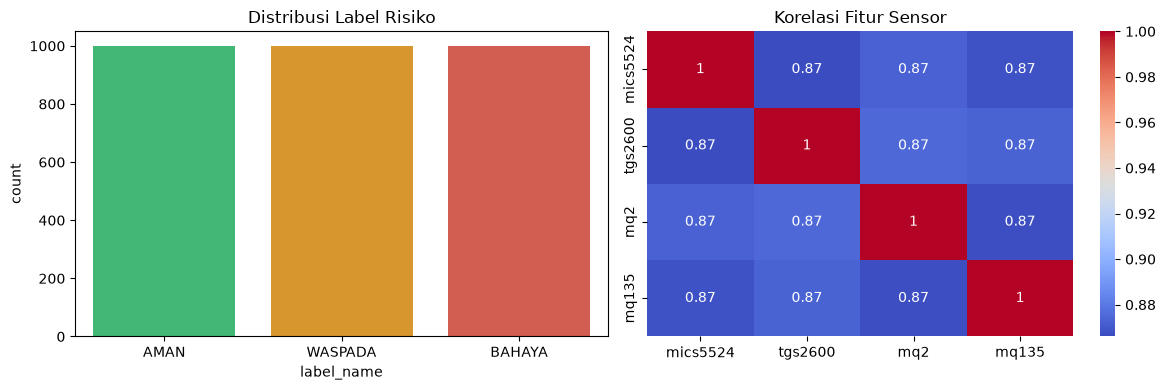

In [22]:
if RUN_MODE == 'TRAINING':
    print("=" * 60)
    print("INFORMASI DATASET SENSOR SIPARTA")
    print("=" * 60)
    print(df.info())
    print("\nStatistik Deskriptif:")
    display(df.describe())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribusi Label
    sns.countplot(data=df, x='label_name', ax=axes[0], palette=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[0].set_title("Distribusi Label Risiko")
    
    # Korelasi antar sensor
    sns.heatmap(df[['mics5524', 'tgs2600', 'mq2', 'mq135']].corr(), annot=True, cmap='coolwarm', ax=axes[1])
    axes[1].set_title("Korelasi Fitur Sensor")
    
    plt.tight_layout()
    plt.show()


In [23]:
if RUN_MODE == 'TRAINING':
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)
    
    print("✅ Preprocessing & Data Split selesai.")
    print(f"   X_train: {X_train_scaled.shape}")
    print(f"   X_test : {X_test_scaled.shape}")


✅ Preprocessing & Data Split selesai.
   X_train: (2400, 4)
   X_test : (600, 4)


In [24]:
def build_edge_model(input_dim=4, num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(input_dim,), name='hidden_1'),
        tf.keras.layers.Dropout(0.2, name='dropout_1'),
        tf.keras.layers.Dense(8, activation='relu', name='hidden_2'),
        tf.keras.layers.Dense(num_classes, activation='softmax', name='output')
    ], name='SIPARTA_Edge_ANN')
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

if RUN_MODE == 'TRAINING':
    model = build_edge_model()
    model.summary()
    
    # Training Model
    history = model.fit(
        X_train_scaled, y_train_cat, 
        epochs=15, 
        batch_size=32, 
        validation_split=0.2, 
        verbose=1
    )


/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/ai_models/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SIPARTA_Edge_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

...

 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 3.3479e-04

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 5.9002e-05


Epoch 15/15


 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 2.9633e-04

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 4.7273e-05



Test Accuracy: 100.00%


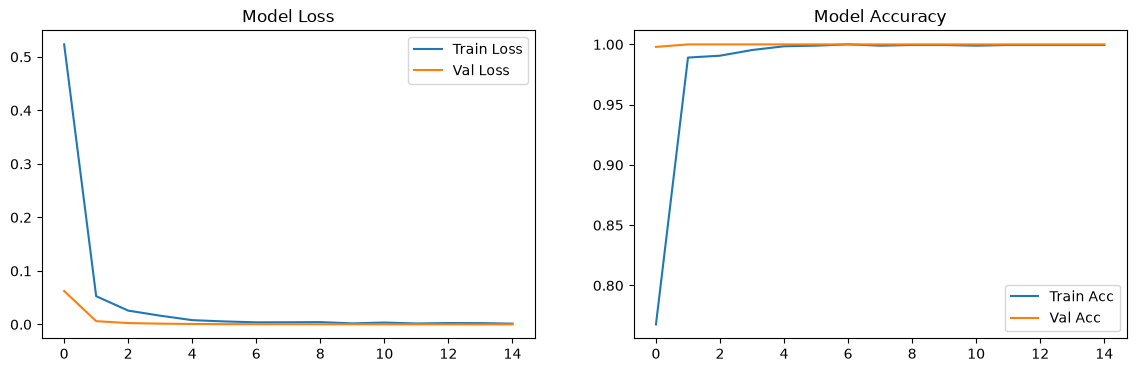

 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 



Classification Report:
              precision    recall  f1-score   support

        AMAN       1.00      1.00      1.00       217
     WASPADA       1.00      1.00      1.00       197
      BAHAYA       1.00      1.00      1.00       186

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



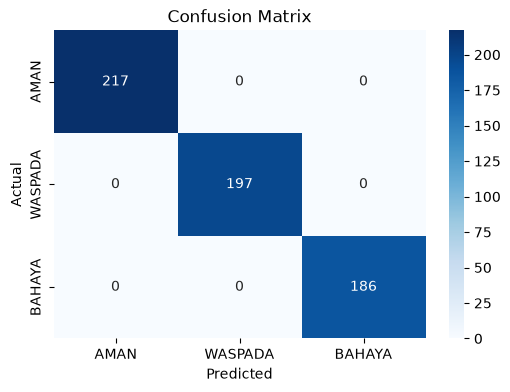

In [25]:
if RUN_MODE == 'TRAINING':
    # Evaluasi Akurasi
    loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
    print(f"\nTest Accuracy: {acc*100:.2f}%")
    
    # Plot History
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Model Loss')
    axes[0].legend()
    
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Model Accuracy')
    axes[1].legend()
    plt.show()
    
    # Classification Report
    y_pred_proba = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_proba, axis=-1)
    
    target_names = ["AMAN", "WASPADA", "BAHAYA"]
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [26]:
if RUN_MODE == 'TRAINING':
    os.makedirs("model", exist_ok=True)
    
    # 1. Simpan Scaler
    with open("model/siparta_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
        
    # 2. Simpan Keras Model
    model.save("model/siparta_ann.keras")
    
    # 3. Konversi dan Simpan TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open("model/siparta_ann.tflite", "wb") as f:
        f.write(tflite_model)
        
    # 4. Simpan Metadata / Config
    config = {
        'sensor_features': ['mics5524', 'tgs2600', 'mq2', 'mq135'],
        'target_names': target_names,
        'num_classes': 3,
        'model_type': 'Edge_ANN_TFLite',
        'export_time': datetime.now(timezone.utc).isoformat()
    }
    with open('model/siparta_config.json', 'w') as f:
        json.dump(config, f, indent=2)
        
    print("✅ Seluruh artefak model (Scaler, Keras, TFLite, Config) berhasil disimpan ke 'model/'.")


INFO:tensorflow:Assets written to: /tmp/tmpghrpl4go/assets


INFO:tensorflow:Assets written to: /tmp/tmpghrpl4go/assets


Saved artifact at '/tmp/tmpghrpl4go'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_56')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139734141666512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139734138557008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139734138562384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139734138561616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139734138556816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139734138562576: TensorSpec(shape=(), dtype=tf.resource, name=None)


✅ Seluruh artefak model (Scaler, Keras, TFLite, Config) berhasil disimpan ke 'model/'.


W0000 00:00:1790927483.732578  295259 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790927483.732587  295259 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790927483.732758  295259 reader.cc:83] Reading SavedModel from: /tmp/tmpghrpl4go
I0000 00:00:1790927483.733072  295259 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790927483.733077  295259 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpghrpl4go
I0000 00:00:1790927483.736045  295259 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790927483.736523  295259 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790927483.752712  295259 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpghrpl4go
I0000 00:00:1790927483.757517  295259 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 24765 microseconds.
I0000 00:00:1790927483.765070  295259

---
# FASE 3: SIMULASI INFERENCE & IOT LOOP
Pada tahap akhir ini, kita mendemonstrasikan bagaimana model yang telah dilatih (TFLite) di-*deploy* dalam *environment* perangkat keras. 
Script di bawah ini bertindak sebagai *Inference Engine* untuk klasifikasi langsung dan pengiriman *payload* ke backend FastAPI.


In [27]:
class InferenceEngine:
    def __init__(self, model_path="model/siparta_ann.tflite", scaler_path="model/siparta_scaler.pkl"):
        self.use_fallback = False
        self.classes = ["AMAN", "WASPADA", "BAHAYA"]
        try:
            self.interpreter = tf.lite.Interpreter(model_path=model_path)
            self.interpreter.allocate_tensors()
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
            
            with open(scaler_path, 'rb') as f:
                self.scaler = pickle.load(f)
            print("✅ InferenceEngine: TFLite Model dan Scaler berhasil diload.")
        except Exception as e:
            print(f"\u26a0\ufe0f Gagal meload model/scaler: {e}")
            self.use_fallback = True

    def preprocess(self, sensor_values):
        # Clipping ekstrim (Fail-safe)
        clamped = [max(0.0, min(5.0, v)) for v in sensor_values]
        input_data = np.array([clamped], dtype=np.float32)
        if hasattr(self, 'scaler'):
            return self.scaler.transform(input_data).astype(np.float32)
        return input_data

    def predict(self, sensor_values):
        if self.use_fallback:
            return "ERROR_MODEL_NOT_LOADED"
            
        try:
            input_data = self.preprocess(sensor_values)
            self.interpreter.set_tensor(self.input_details[0]['index'], input_data)
            self.interpreter.invoke()
            output = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
            
            pred_class = np.argmax(output)
            confidence = output[pred_class]
            return self.classes[pred_class], confidence
        except Exception as e:
            print(f"Inference error: {e}")
            return "ERROR_INFERENCE_FAILED", 0.0

# Instantiate engine (digunakan saat eksekusi loop IoT)
engine = InferenceEngine()


✅ InferenceEngine: TFLite Model dan Scaler berhasil diload.


/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/ai_models/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [28]:
def simulate_read_sensors(iteration):
    # Dummy reading [mics5524, tgs2600, mq2, mq135]
    dummy_scenarios = [
        [0.4, 0.5, 0.2, 0.3], # AMAN
        [1.5, 1.8, 1.3, 1.6], # WASPADA
        [3.5, 4.0, 3.2, 4.5], # BAHAYA
        [0.8, 0.6, 0.5, 0.7], # AMAN
        [4.8, 4.5, 4.9, 4.7]  # BAHAYA
    ]
    return dummy_scenarios[iteration % len(dummy_scenarios)]

def send_report_to_backend(sensor_data, status, confidence, is_simulation=True):
    payload = {
        "status": status,
        "confidence": float(confidence),
        "sensor_mics5524": float(sensor_data[0]),
        "sensor_tgs2600": float(sensor_data[1]),
        "sensor_mq2": float(sensor_data[2]),
        "sensor_mq135": float(sensor_data[3]),
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "device_id": "SIMULATION_01" if is_simulation else "PRODUCTION_RPi3"
    }
    print(f"--> [API POST] Data terkirim: {json.dumps(payload, indent=2)}")
    return True

if RUN_MODE in ['SIMULATION', 'HARDWARE_TEST', 'PRODUCTION_INTEGRATION']:
    print(f"\n=== Memulai IoT Loop Mode: [{RUN_MODE}] ===")
    
    try:
        for i in range(MAX_SIMULATION_ITERATIONS):
            print(f"\n--- Iterasi {i+1}/{MAX_SIMULATION_ITERATIONS} ---")
            
            # 1. Akuisisi Data
            if RUN_MODE == 'SIMULATION':
                sensor_data = simulate_read_sensors(i)
                print(f"[SENSOR] Simulasi ADC (MICS, TGS, MQ2, MQ135): {sensor_data}")
            else:
                print("[SENSOR] Membaca hardware I2C ADS1115 (Fisik) ...")
                # sensor_data = hw_read_sensors()
                sensor_data = [0.0, 0.0, 0.0, 0.0]
                
            # 2. Klasifikasi JST
            status, conf = engine.predict(sensor_data)
            print(f"[AI/JST] Status: {status} (Conf: {conf*100:.1f}%)")
            
            # 3. Logika Aksi / Aktuator & Pelaporan
            if status.startswith("ERROR"):
                print("[FAIL-SAFE] Sistem Gagal. Komunikasi keluar diblokir.")
            elif status in ["WASPADA", "BAHAYA"]:
                print(f"[ALARM] Triggering aktuator (Kipas/Buzzer).")
                send_report_to_backend(sensor_data, status, conf, is_simulation=(RUN_MODE=='SIMULATION'))
            else:
                print(f"[OK] Kondisi stabil. Menyimpan ke log lokal.")
                
            time.sleep(1)
            
    except KeyboardInterrupt:
        print("\n[STOP] Loop dihentikan (KeyboardInterrupt).")
    
    print("=== IoT Loop Selesai ===")
